# Python for Economics and Finance
## Scientific Library
### 2 Matrix Algebra and Linear Algebra using Numpy and Scipy
### Shutao Cao
#### 2026-01-23

## Matrix Algebra

### Vector norm
The norm of a vector $\textbf{x}$, written as $\left \Vert \textbf{x} \right \|$, is a measure of the length of vector $\textbf{x}$. There are different definitions of norms. The **Euclidian norm** of an $n$-dimensional vector is defined as  $\left \Vert \textbf{x} \right \| = \left(\sum_{i}^n{x_i}^2\right)^{\frac{1}{2}}$

In [1]:
#import scipy.linalg as LA
import numpy as np
import numpy.linalg as LA
x = np.arange(5) - 2
print(x)
norm_x = LA.norm(x)
print(norm_x)

[-2 -1  0  1  2]
3.1622776601683795


### Matrix inverse
$\mathbf{A}^{-1} \mathbf{A} = \mathbf{I}$. Only square matrix can have inverse.

In [2]:
x = np.random.rand(4,4)
xinv = np.linalg.inv(x)
print(xinv)

[[ -4.99127582   3.09182025  10.84537529  -3.29699516]
 [  7.79991478  -4.83604278 -12.46668902   3.09938164]
 [  3.79304401  -0.1532197   -7.34896267   1.68904786]
 [ -7.7713744    4.41792041  12.64172607  -2.08696962]]


### Determinants
To get the determinant of a matrix, you can call NumPy's `det` function in the `numpy.linalg` module.

In [3]:
LA.det(x)

0.01979361728482983

### Eigenvectors and eigenvalues
If $\mathbf{A x} = \lambda \mathbf{x}$,  then $\lambda$ is the **eigenvalue** associated to the eigenvector $\mathbf{x}$.

In [4]:
eigenvalues, eigenvectors = LA.eig(x)
eigenvalues # returns all eigenvalues of A

array([ 1.60850674,  0.62730346, -0.05329913, -0.36804804])

In [5]:
eigenvectors # [v0, v1, …]

array([[-0.6763777 , -0.71409935, -0.47398264,  0.26748103],
       [-0.28815642, -0.21153361,  0.61801749, -0.75329964],
       [-0.42776086, -0.17776781,  0.25089396,  0.40559532],
       [-0.52583241,  0.64320623, -0.57484525,  0.44326741]])

### Solving a system of linear equations:
\begin{align*}3 x_0 + 2 x_1 - x_2 = 9 \\ x_0 - 2 x_1 + 0.5x_2 = 2 \\  5 x_0 +0.2x_1 - 2x_2 = 10 \end{align*}
In matrix, $A x = b$

In [6]:
# from numpy import linalg
A = np.array([[3, 2, -1], [1,-2, 0.5], [5,0.2,-2]])
b = np.array([9,2,10])
x = np.linalg.solve(A, b)
print('x=',x)

x= [3.11428571 1.28571429 2.91428571]


### Singular value decomposition

In [7]:
# Singular value decomposition
x = np.random.rand(4,4)
U, S, Vh = np.linalg.svd(x)
print(U)
print(S)
print(Vh)

[[-0.64466426  0.42732755 -0.02733606 -0.63328658]
 [-0.54612988  0.29228155 -0.19119084  0.76141954]
 [-0.29356203 -0.2246334   0.92294216  0.10741947]
 [-0.44718171 -0.82553164 -0.33298135 -0.08746112]]
[2.31294    0.58488934 0.24410279 0.19974653]
[[-0.54936822 -0.31286496 -0.61560877 -0.47046352]
 [ 0.3290433  -0.37828183 -0.58710244  0.63556597]
 [-0.16991527  0.86114996 -0.43667753  0.1971352 ]
 [-0.74903529 -0.13205728  0.29265905  0.57953231]]


SVD is important in data science. One use of it is to use a low-rank matrix to approximation a big matrix. This is useful for image compressing.

In the example below, we read in an RGB image into Python, 

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt
from PIL import Image
im = Image.open("./images/bird.jpg")
im_data = np.asarray(im)
print(type(im_data))
im_data.shape

<class 'numpy.ndarray'>


(710, 1024, 3)

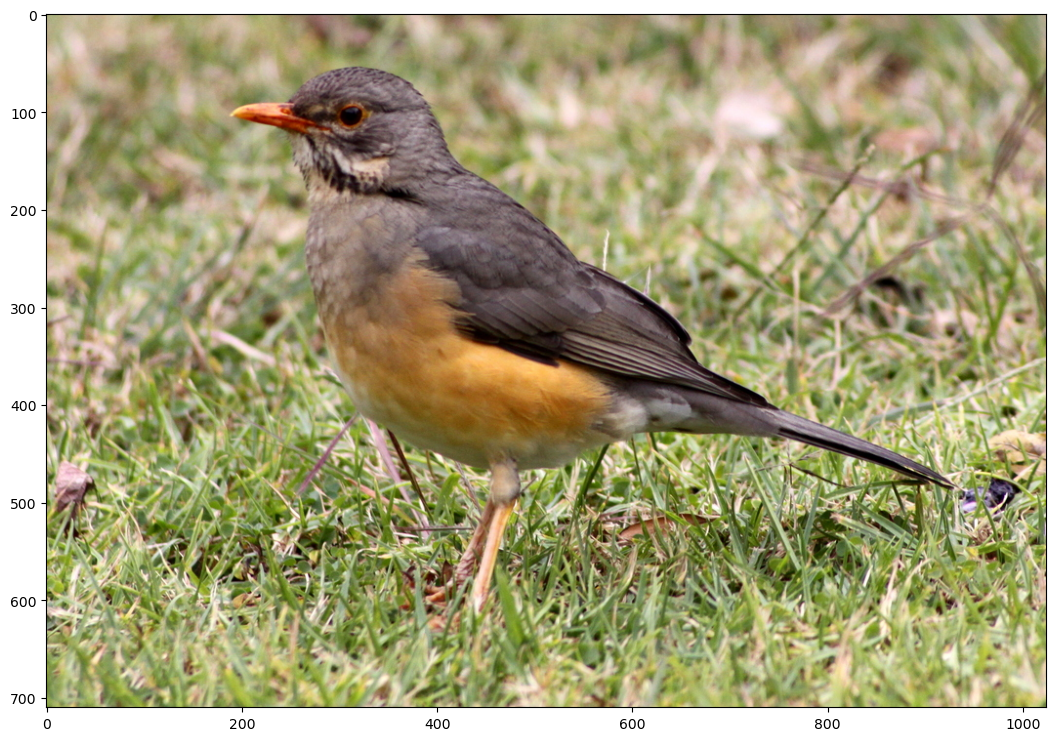

In [11]:
plt.figure(figsize=(18,9))
imgplot = plt.imshow(im_data)

`im_data` is a 3-dimension Numpy array. The first two axes are a matrix of pixels, each element [i,j] represents the brightness of the ij-the pixel. The small the value of pixel, the brighter it is. The 3rd axis represents the color R, G, B respectively.

In [13]:
im_data[:10,:10,1]

array([[176, 175, 178, 174, 178, 176, 175, 173, 177, 176],
       [172, 171, 173, 177, 176, 180, 179, 175, 178, 175],
       [172, 173, 175, 175, 175, 177, 176, 176, 177, 176],
       [176, 176, 178, 176, 178, 180, 175, 176, 178, 177],
       [177, 175, 176, 177, 173, 178, 178, 177, 178, 182],
       [170, 173, 173, 175, 175, 172, 179, 177, 180, 180],
       [174, 173, 170, 170, 176, 173, 181, 182, 179, 175],
       [174, 171, 173, 175, 173, 175, 176, 179, 177, 174],
       [174, 173, 172, 171, 177, 175, 179, 181, 179, 177],
       [178, 176, 173, 173, 178, 175, 175, 175, 178, 177]], dtype=uint8)

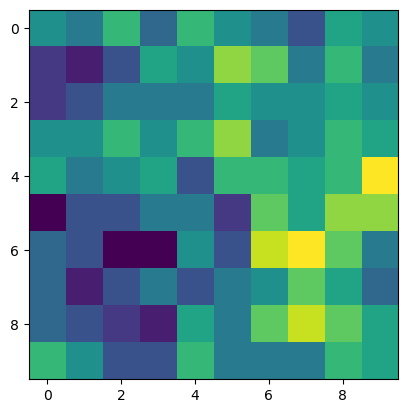

In [14]:
plt.figure()
imgplot = plt.imshow(im_data[:10,:10,1])

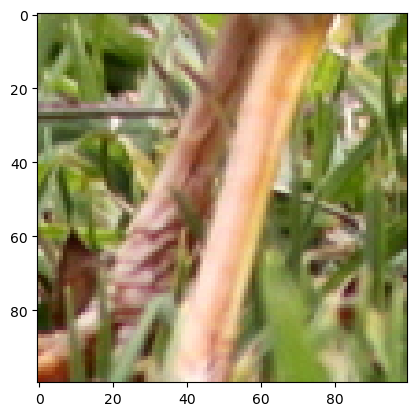

In [12]:
# plot the region with bird's legs
plt.figure()
imgplot = plt.imshow(im_data[500:600,400:500,:])

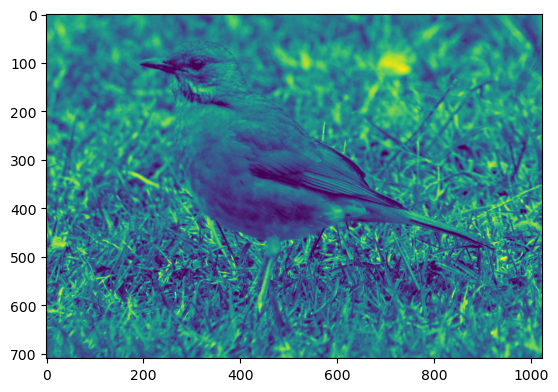

In [13]:
plt.figure()
imgplot = plt.imshow(im_data[:,:,2])

In [14]:
#translating a color image to grayscale (mode “L”)
imx = im.convert('L')
im_dataGray = np.asarray(imx)
imx.save("bird_grayscale.jpg")
print(type(im_dataGray))
im_dataGray.shape

<class 'numpy.ndarray'>


(710, 1024)

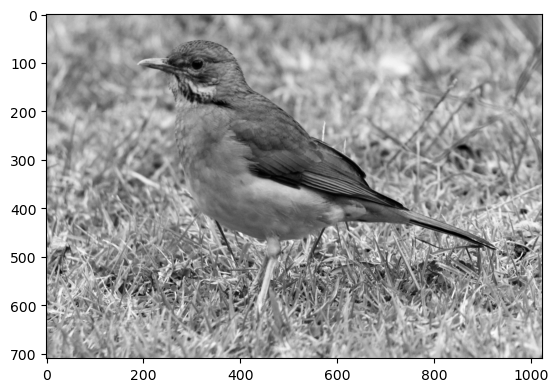

In [15]:
plt.figure()
imgplot = plt.imshow(imx,cmap='gray')

We can use low-rank matrix to approximate the image matrix `im_dataGray` by using SVD.

This is useful for two reasons:
1. Low-rank matrix saves storage space.
2. Often only some part of an image is useful, the rest can be ignored.

In [16]:
u, s, vt = np.linalg.svd(im_dataGray, full_matrices=False)
u.shape, s.shape, vt.shape

((710, 710), (710,), (710, 1024))

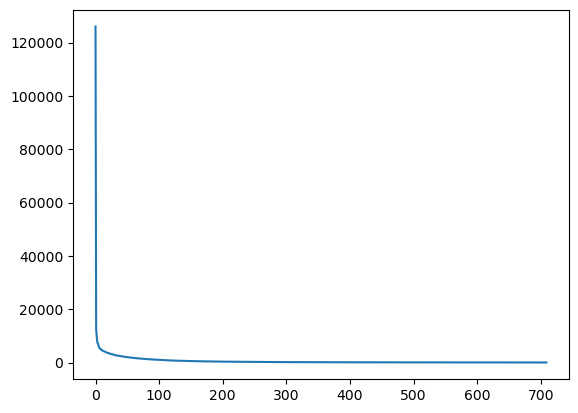

In [17]:
x= plt.plot(s)
plt.show()

The grayscale image matrix has 710 singular values, ordering from the largest to the smallest. We examine how good the image quality is when we use a low-rank matrix to represent the image.

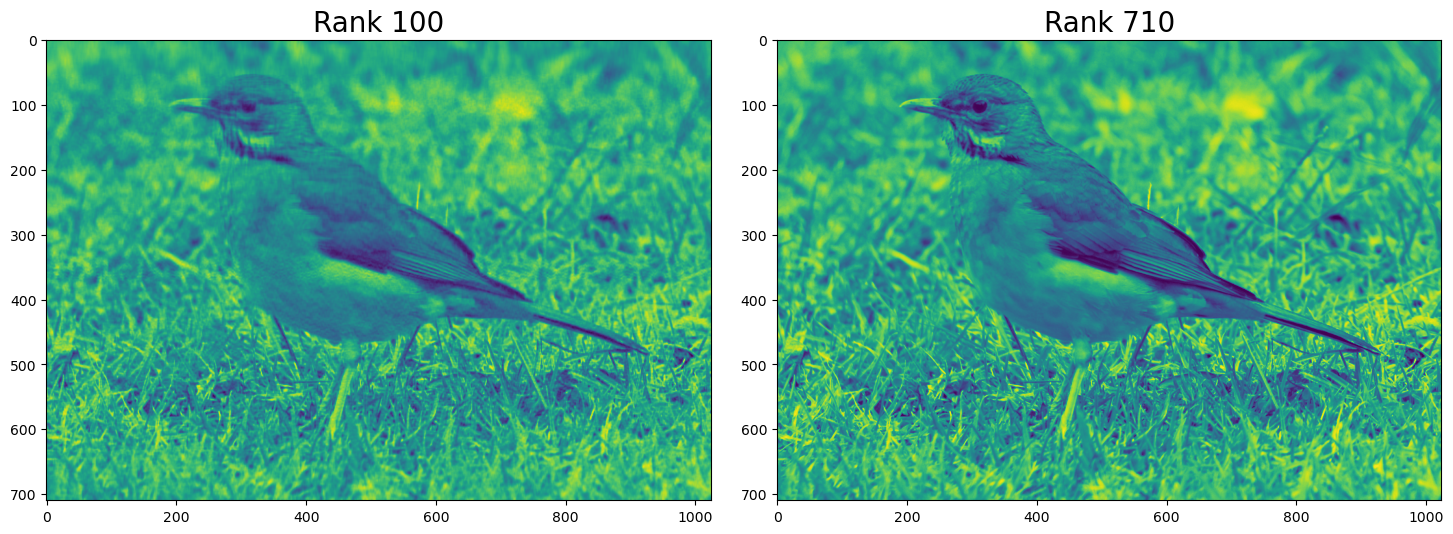

In [18]:
scopy = s.copy()
rank = 100
scopy[rank:]=0
birdApprox = u @ np.diag(scopy) @ vt
plt.figure(figsize=(18,9))
plt.subplot(1,2,1)
plt.imshow(birdApprox)
plt.title(f'Rank {rank}', size=20)
plt.subplot(1,2,2)
plt.imshow(im_dataGray)
plt.title('Rank 710', size=20)
plt.subplots_adjust(wspace=0.1);

### Applications of SVD in statistics

The same idea applies to statistics data.

In unsupervised machine learning, SVD is applied to the principal component analysis (PCA)

to find the main components of total variance of data. This technical is used in matrix completion and the recommendation system, for example that in Netflix.

In economics and finance, cross-section data of households and firms often have missing values for some features (variables). Traditionally, observations with missing values are thrown away in regressions, which can create biases in estimation.

Using PCA, one can impute the missing values.

## Further reading

[Numpy User Guide](https://numpy.org/doc/stable/user/index.html)

For linear algebra library in Numpy, see https://numpy.org/doc/stable/reference/routines.linalg.html.

Scipy also has a similar linear algebra library.